# Decision Tree Regression

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('student-mat.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

## One Hot Encoding

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0, 2, 3, 4, 7, 8, 9, 10, 14, 15, 16, 17, 18, 19, 20, 21 ])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

# Splitting the dataset 

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Training the Decision Tree Regression model on the whole dataset

In [5]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state = 0)
regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

# Predicting the Test Result

In [6]:
y_pred = regressor.predict(X_test)

print("Predicted values:")
print(y_pred)

print("Actual values:")
print(y_test)


Predicted values:
[15.   10.   11.   16.   17.   12.   14.   13.   10.   15.    9.   11.
  9.   10.   15.   13.   13.    0.   10.   15.    0.    0.    0.   15.
 14.   18.   10.   19.    0.   14.    0.    9.    8.    8.   13.   11.
 12.   18.   12.    8.25  8.25 19.   11.    8.   10.    0.   13.    0.
 13.    0.   10.   18.   13.   10.   11.   10.   10.   13.   15.   13.
 13.   14.   13.   14.    9.    8.25 18.   14.    6.    9.   10.   14.
  5.    0.    8.   11.   11.   18.    0.  ]
Actual values:
[14 10  9 15 16 12 14 11  9 15 10 11 10  8 15 14 12  0 10 16  0  0  8 16
 12 15 10 19  0 14  0 10  8  4 13 10 13 18  8 12  7 18  8  8 11  0 13  0
 13  7 10 18 10  9 11  6  9 13 15 14 14 15 14 15  0 11 19 12  6  9  8 15
  5  0  9  0 11 18  0]


# Evaluating the Model

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 score: 0.7852465416240251
MAE: 1.2753164556962024


## Feature Extraction

In [8]:
original_feature_names = dataset.columns[1:-1]

encoded_feature_names = ct.get_feature_names_out(original_feature_names)
clean_feature_names = [name.replace('encoder__', '').replace('remainder__', '') for name in encoded_feature_names]

feature_importance = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': regressor.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance.head(15))

              Feature  Importance
55                 G2    0.808630
53           absences    0.065980
41                age    0.040726
18      reason_course    0.024908
31      activities_no    0.015724
44         traveltime    0.010338
48           freetime    0.009220
54                 G1    0.003306
45          studytime    0.001702
22    guardian_father    0.001674
21  reason_reputation    0.001291
52             health    0.001108
39        romantic_no    0.001078
2           address_R    0.001045
11      Mjob_services    0.001017


## Plotting Feature Extraction

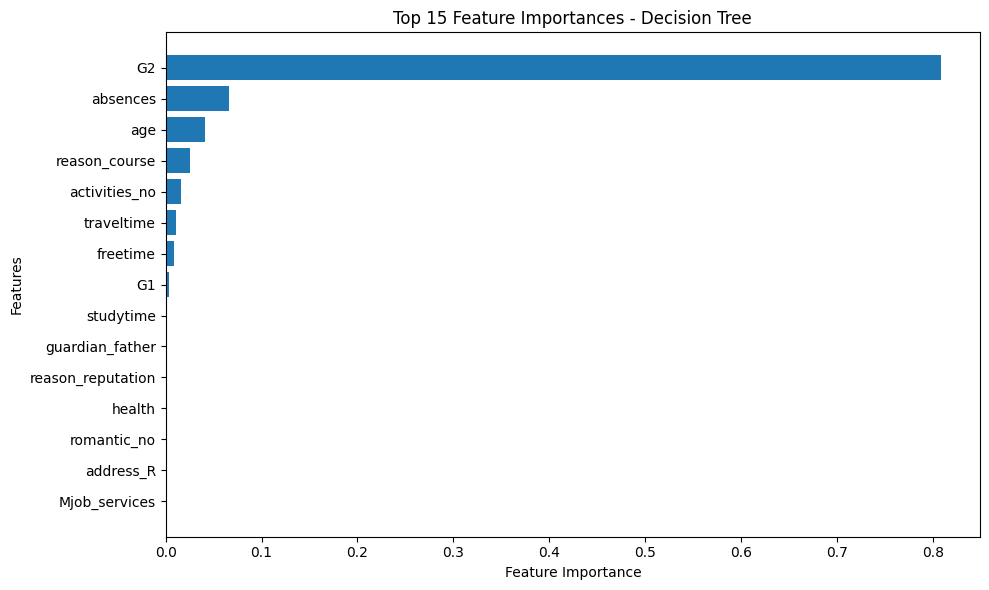

In [9]:
top_n = 15
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()